In [8]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Test rectangle primitive
xc, yc = 0.0, 0.5
w, h = 2.0, 0.5
alpha=0.0

rect = Rectangle(center=(xc, yc), 
                 size=(w, h), 
                 angle=alpha)

NameError: name 'Rectangle' is not defined

In [2]:
from metashapes.shape import Rectangle, RoundedRectangle, RoundedCross, Ellipse, RoundedRegularPolygon, RoundedMoon, Shape, Difference, Rotate, Translate
from metashapes.adapters import shape_to_shapely, shape_to_numpy
from metashapes import Canvas
from metashapes.patterned_layer import PatternedLayer

rect = RoundedRectangle(center=(20.0, 0.0), size=(120.0, 80.0), radius=40.0, angle=0.0)
hole = Ellipse(center=(0.0, 0.0), axes=(40.0, 30.0), angle=45.0)
ngn = RoundedRegularPolygon(center=(0.0, 0.0), n=5, side_length=30.0, angle=0.0, radius=4.0)
moon_shape = RoundedMoon(center=(0.0, 90.0), radius=40.0, cut_ratio=0.5, angle=90.0, rounding_radius=5.0)
cross_shape = RoundedCross(center=(70.0, 50.0), size=30.0, width=8.0, radius=2, angle=30.0)

shape_comb = (rect.rotate(15) - hole).rotate(0).translate(0, 0).union(ngn).union(moon_shape).translate(30, -20).rotate(45).difference(cross_shape)

print(shape_comb.to_parametric())

shape = Shape.from_parametric(shape_comb.to_parametric())

{'type': 'Difference', 'left': {'type': 'Rotate', 'shape': {'type': 'Translate', 'shape': {'type': 'Union', 'left': {'type': 'Union', 'left': {'type': 'Translate', 'shape': {'type': 'Rotate', 'shape': {'type': 'Difference', 'left': {'type': 'Rotate', 'shape': {'type': 'RoundedRectangle', 'center': [20.0, 0.0], 'size': [120.0, 80.0], 'radius': 40.0, 'angle': 0.0}, 'angle': 15, 'origin': (0.0, 0.0)}, 'right': {'type': 'Ellipse', 'center': [0.0, 0.0], 'axes': [40.0, 30.0], 'angle': 45.0, 'resolution': 64}}, 'angle': 0, 'origin': (0.0, 0.0)}, 'dx': 0, 'dy': 0}, 'right': {'type': 'RoundedRegularPolygon', 'center': [0.0, 0.0], 'n': 5, 'side_length': 30.0, 'radius': 4.0, 'angle': 0.0}}, 'right': {'type': 'RoundedMoon', 'center': [0.0, 90.0], 'radius': 40.0, 'cut_ratio': 0.5, 'rounding_radius': 5.0, 'angle': 90.0, 'resolution': 64}}, 'dx': 30, 'dy': -20}, 'angle': 45, 'origin': (0.0, 0.0)}, 'right': {'type': 'RoundedCross', 'center': [70.0, 50.0], 'size': 30.0, 'width': 8.0, 'radius': 2, 'angl

In [3]:
# Create Canvas
Lx = 200
Ly = 200
H = 400
W = 400

canv = Canvas(Lx, Ly, H, W, spacing=0.2)

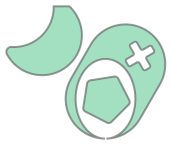

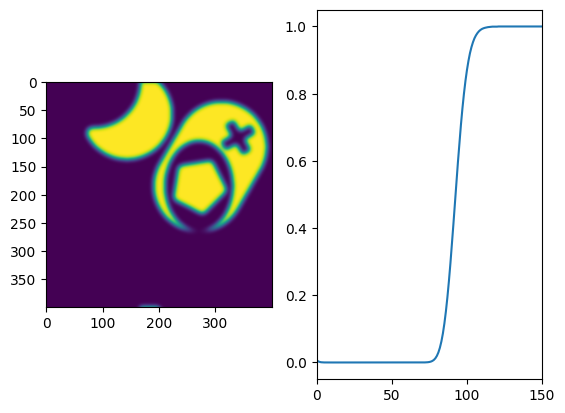

In [39]:
soft_bool = True
mode = "fourier"
softness = 2

pl = PatternedLayer(shape_comb, canvas=canv, thickness=5, inverted=False)

plt.subplot(121)
plt.imshow(pl.filled_region.to_numpy(canv, dtype=np.float16, soft=soft_bool, soft_mode=mode, softness=softness))
plt.subplot(122)
plt.plot(pl.filled_region.to_numpy(canv, dtype=np.float16, soft=soft_bool, soft_mode=mode, softness=softness)[120,:])
plt.xlim([0, 150])
pl.filled_region.to_shapely()

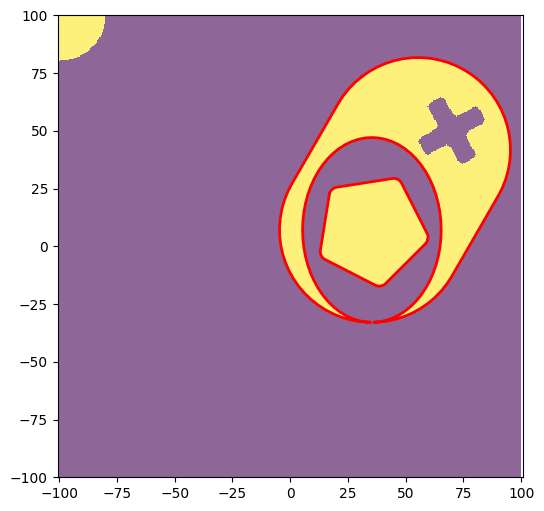

In [15]:
mask = shape_to_numpy(shape, canv)
geom = shape_to_shapely(shape)

plt.figure(figsize=(6, 6))

plt.imshow(
    mask,
    extent=(canv.x0, canv.x1, canv.y0, canv.y1),
    origin="upper",
    interpolation="nearest",
    alpha=0.6,
)

# plot shapely outline
if geom.geom_type == "Polygon":
    x, y = geom.exterior.xy
    plt.plot(x, y, "r-", lw=2)

elif geom.geom_type == "MultiPolygon":
    for poly in geom.geoms:
        x, y = poly.exterior.xy
        plt.plot(x, y, "r-", lw=2)

plt.axis("equal")
plt.show()

1.9654619396218376


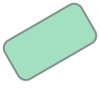

In [3]:
# Test rounded rectangle primitive
xc, yc = 0.0, 0.0
w, h = 2.0, 1.0
alpha=30
radius=0.2

rrect = rounded_rectangle(center=(xc, yc), size=(w, h), angle=alpha, radius=radius)
print(rrect.area)
rrect.geom

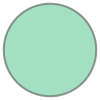

In [46]:
# Test ellipse primitive
xc, yc = 0.0, 0.0
w, h = 2.0, 2.0
alpha=0

ellipse_shape = ellipse(center=(xc, yc), axes=(w/2, h/2), angle=alpha)
ellipse_shape.geom

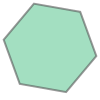

In [50]:
# Test ngon primitive
xc, yc = 0.0, 0.0
n = 6
side_length = 0.5
alpha = 20

poly = regular_polygon(center=(xc, yc), n = n, side_length=side_length, angle=alpha)
poly.geom

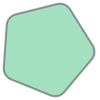

In [52]:
# Test rounded ngon primitive
xc, yc = 0.0, 0.0
n = 5
side_length = 1.0
alpha = 50
radius = 0.2
rounded_poly = rounded_regular_polygon(center=(xc, yc), n = n, side_length=side_length, angle=alpha, radius=radius)
rounded_poly.geom

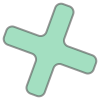

In [43]:
# Test cross primitive
xc, yc = 0.0, 0.0
size = 2.0
width = 0.4
alpha = -20
radius = 0.13
cross_shape = rounded_cross(center=(xc, yc), size=size, width=width, radius=radius, angle=alpha)
cross_shape.geom

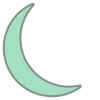

In [72]:
# Test moon primitive
xc, yc = 0.0, 0.0
radius = 0.5
cut_ratio = 0.8
angle = 30
rounding_radius = 0.01

moon_shape = rounded_moon(center=(xc, yc), radius=radius, cut_ratio=cut_ratio, rounding_radius=rounding_radius, angle=angle)
moon_shape.geom

In [83]:
# Create Canvas
Lx = 3
Ly = 3
H = 300
W = 300

canv = Canvas(Lx, Ly, H, W, spacing=0.2)

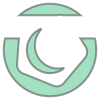

In [85]:
# Combine shapes
shape1 = (ellipse_shape - rounded_poly - rect).union(moon_shape)

pl = PatternedLayer(shape=shape1, canvas=canv, thickness=0.5, inverted=False)
pl.filled_region.geom

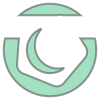

In [88]:
pl2 = PatternedLayer.from_parametric(pl.to_parametric())
pl2.filled_region.geom

In [89]:
pl.to_parametric()

{'shape': 'MULTIPOLYGON (((0.9569403357322088 -0.2902846772544623, 0.9238795325112867 -0.3826834323650898, 0.881921264348355 -0.4713967368259976, 0.8314696123025452 -0.5555702330196022, 0.773010453362737 -0.6343932841636455, 0.7071067811865476 -0.7071067811865475, 0.6343932841636455 -0.773010453362737, 0.5555702330196023 -0.8314696123025452, 0.4713967368259978 -0.8819212643483549, 0.3826834323650898 -0.9238795325112867, 0.2902846772544623 -0.9569403357322088, 0.1950903220161283 -0.9807852804032304, 0.0980171403295608 -0.9951847266721968, 0 -1, -0.0980171403295606 -0.9951847266721969, -0.1950903220161282 -0.9807852804032304, -0.2902846772544622 -0.9569403357322089, -0.3826834323650897 -0.9238795325112867, -0.4713967368259977 -0.881921264348355, -0.555570233019602 -0.8314696123025453, -0.6343932841636454 -0.7730104533627371, -0.7071067811865475 -0.7071067811865476, -0.773010453362737 -0.6343932841636455, -0.8314696123025453 -0.5555702330196022, -0.8819212643483549 -0.4713967368259979, -0